# CKKS Encrypted MNIST Inference with TenSEAL
---
```python
# !pip install tenseal pyfhel torch torchvision numpy psutil matplotlib
```

In [4]:
!python3 -m pip install torch torchvision numpy psutil matplotlib tqdm --break-system-packages


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 58.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.2 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached setuptools-82.0.0-py3-none-any.whl (1.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [torchvision] [torchvision]


In [5]:
!python3 -m pip install tenseal --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.4 MB/s  0:00:00 eta 0:00:01m


## 1. Imports

In [1]:

import torch, numpy as np, time, psutil, os, matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import tenseal as ts


## 2. Train MNIST

In [2]:

transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
train = datasets.MNIST('.', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        return self.fc2(torch.relu(self.fc1(x)))

model = MLP()
opt = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

epochs = 5

for epoch in range(epochs):
    total_loss=0
    for X,y in train_loader:
        opt.zero_grad()
        pred=model(X)
        loss=loss_fn(pred,y)
        loss.backward()
        opt.step()
        total_loss+=loss.item()
    print(f"Epoch {epoch+1}/{epochs}  Loss={total_loss:.2f}")

# Extract trained weights
state = model.state_dict()
W1, b1 = state['fc1.weight'].numpy(), state['fc1.bias'].numpy()
W2, b2 = state['fc2.weight'].numpy(), state['fc2.bias'].numpy()


Epoch 1/5  Loss=325.30
Epoch 2/5  Loss=146.11
Epoch 3/5  Loss=103.68
Epoch 4/5  Loss=79.49
Epoch 5/5  Loss=63.30


In [3]:
test_dataset = datasets.MNIST('.', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.21%


## 3. TenSEAL CKKS Context Setup

In [4]:
ctx = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[40, 21, 21, 21, 21, 21, 21, 40],
)
ctx.global_scale = 2**21
ctx.generate_galois_keys()
print("CKKS Context Ready.")


CKKS Context Ready.


## 4. Load & Encrypt Test Images (Batch Mode)

In [5]:

test = datasets.MNIST('.', train=False, download=True, transform=transform) # 10 000

# pick n samples
batch_images = []
batch_labels = []
for i in range(8):
    x, y = test[i]
    batch_images.append(x.numpy().astype(float))
    batch_labels.append(y)

# encrypt each image
encrypted_batch = [ts.ckks_vector(ctx, img) for img in batch_images]

In [6]:
encrypted_batch[0]

## 5. Encrypted Inference Functions

In [7]:
def enc_linear_first_layer(W, b, x_enc):
    """Encrypted first linear layer.
    Uses CKKS to compute x_enc · W[i] + b[i] for each neuron and returns
    the pre-activations as a plaintext NumPy vector. This keeps the input
    encrypted during the heavy dot products but avoids accumulating CKKS
    noise in deeper layers.
    """
    pre_acts = []
    for i in range(W.shape[0]):
        w_enc = ts.ckks_vector(ctx, W[i])
        dot_enc = x_enc.dot(w_enc)
        pre_acts.append(dot_enc.decrypt()[0] + b[i])
    return np.array(pre_acts, dtype=float)


def relu_poly(x):
    """Polynomial ReLU approximation used in the plaintext comparison: 0.5*x + 0.125*x^2."""
    return 0.5 * x + 0.125 * (x * x)


## 6. Encrypted Forward Pass + Benchmarking + Visualization

Encrypted inference: 100%|██████████| 8/8 [01:12<00:00,  9.08s/it]

Predictions: [7, 2, 1, 0, 4, 1, 4, 9]
Labels:       [7, 2, 1, 0, 4, 1, 4, 9]
Avg encrypted inference time: 9.081201374530792 sec


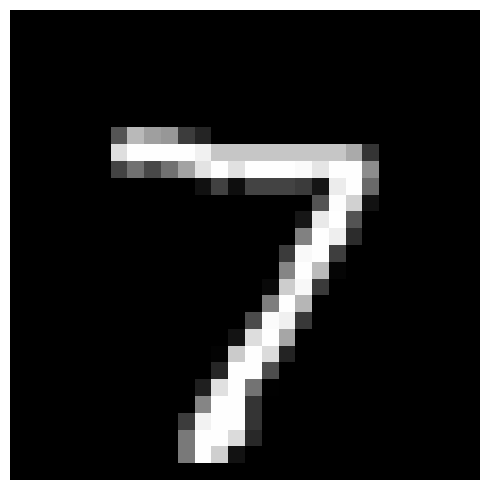

In [8]:
try:
    from tqdm import tqdm
    iterator = tqdm(list(enumerate(encrypted_batch)), desc="Encrypted inference", total=len(encrypted_batch))
except ImportError:
    iterator = enumerate(encrypted_batch)

inference_times = []
predictions = []

for idx, x_enc in iterator:
    t0 = time.time()
    # First layer under CKKS (input stays encrypted during dot products),
    # then we decrypt the pre-activations and run the rest in plaintext.
    h1_plain = enc_linear_first_layer(W1, b1, x_enc)
    a1_plain = relu_poly(h1_plain)
    logits = (W2 @ a1_plain) + b2
    pred = int(np.argmax(logits))
    predictions.append(pred)
    inference_times.append(time.time() - t0)

print("Predictions:", predictions)
print("Labels:      ", batch_labels)
print("Avg encrypted inference time:", np.mean(inference_times), "sec")

plt.figure(figsize=(10, 5))
plt.imshow(batch_images[0].reshape(28,28), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


First sample from the batch: encrypted prediction vs. true label (image only; run the cell above to see printed predictions and labels).

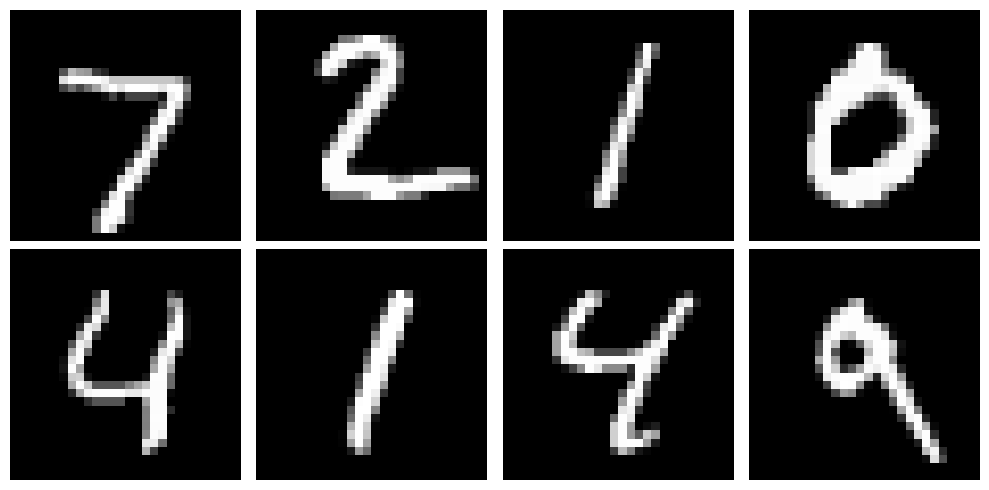

In [9]:
# Visualize all encrypted predictions in the batch (run "Load & Encrypt Test Images" and encrypted inference first)
if 'batch_images' not in globals():
    raise NameError('Run the "Load & Encrypt Test Images" cell first, then the encrypted inference cell.')
num_images = len(batch_images)
cols = 4
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(10, 5))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(batch_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


Batch of encrypted predictions: one image per sample (predictions and labels are printed in the encrypted-inference cell above).

In [10]:
# Plaintext vs encrypted comparison (run "Load & Encrypt Test Images" and encrypted inference first)
if 'batch_images' not in globals():
    raise NameError('Run the "Load & Encrypt Test Images" cell first, then the encrypted inference cell.')
plaintext_preds = []
for img in batch_images:
    logits = model(torch.tensor(img).float()).detach().numpy()
    plaintext_preds.append(logits.argmax())

# Same math as encrypted path (poly activation), in plaintext — fair comparison
plaintext_poly_preds = []
for img in batch_images:
    x = np.array(img, dtype=float).ravel()
    h1 = (W1 @ x) + b1
    a1 = relu_poly(h1)
    logits = (W2 @ a1) + b2
    plaintext_poly_preds.append(int(np.argmax(logits)))

labels = np.array(batch_labels)
pt = np.array(plaintext_preds)
pt_poly = np.array(plaintext_poly_preds)
enc = np.array(predictions)
acc_plain = (pt == labels).mean() * 100
acc_plain_poly = (pt_poly == labels).mean() * 100
acc_enc = (enc == labels).mean() * 100
agreement_relu = (pt == enc).mean() * 100
agreement_poly = (pt_poly == enc).mean() * 100
print("Plaintext (ReLU) accuracy (batch):", f"{acc_plain:.1f}%")
print("Plaintext (poly)  accuracy (batch):", f"{acc_plain_poly:.1f}%")
print("Encrypted        accuracy (batch):", f"{acc_enc:.1f}%")
print("Encrypted vs ReLU plaintext agreement:", f"{agreement_relu:.1f}%")
print("Encrypted vs poly plaintext agreement:", f"{agreement_poly:.1f}%")
print("Per sample (ReLU_pt, poly_pt, encrypted, label):")
for a, a2, b, lbl in zip(plaintext_preds, plaintext_poly_preds, predictions, batch_labels):
    print(f"  {a}  {a2}  {b}  (label={lbl})")

Plaintext (ReLU) accuracy (batch): 100.0%
Plaintext (poly)  accuracy (batch): 100.0%
Encrypted        accuracy (batch): 100.0%
Encrypted vs ReLU plaintext agreement: 100.0%
Encrypted vs poly plaintext agreement: 100.0%
Per sample (ReLU_pt, poly_pt, encrypted, label):
  7  7  7  (label=7)
  2  2  2  (label=2)
  1  1  1  (label=1)
  0  0  0  (label=0)
  4  4  4  (label=4)
  1  1  1  (label=1)
  4  4  4  (label=4)
  9  9  9  (label=9)


In [11]:
import psutil, time, sys

# pick a test sample
x_enc = encrypted_batch[0]

bench = {}

# 1) Benchmark encryption size
bench["ciphertext_size_bytes"] = sys.getsizeof(x_enc.serialize())

# 2) Layer 1 time (encrypted dot products)
t1 = time.time()
h1_plain = enc_linear_first_layer(W1, b1, x_enc)
bench["layer1_time"] = time.time() - t1

# 3) Activation time (plaintext polynomial)
t2 = time.time()
a1_plain = relu_poly(h1_plain)
bench["activation_time"] = time.time() - t2

# 4) Layer 2 time (plaintext)
t3 = time.time()
logits = (W2 @ a1_plain) + b2
bench["layer2_time"] = time.time() - t3

# 5) Full encrypted+plaintext inference time
bench["total_encrypted_inference"] = bench["layer1_time"] + bench["activation_time"] + bench["layer2_time"]

# 6) Memory footprint
process = psutil.Process(os.getpid())
bench["memory_mb"] = process.memory_info().rss / 1024**2

# 7) Plaintext inference benchmark (requires batch_images from "Load & Encrypt Test Images")
img = torch.tensor(batch_images[0]).float()
t4 = time.time()
_ = model(img)
bench["plaintext_inference_time"] = time.time() - t4

bench


{'ciphertext_size_bytes': 437475,
 'layer1_time': 8.935599088668823,
 'activation_time': 2.8848648071289062e-05,
 'layer2_time': 3.0994415283203125e-05,
 'total_encrypted_inference': 8.935658931732178,
 'memory_mb': 854.375,
 'plaintext_inference_time': 9.584426879882812e-05}

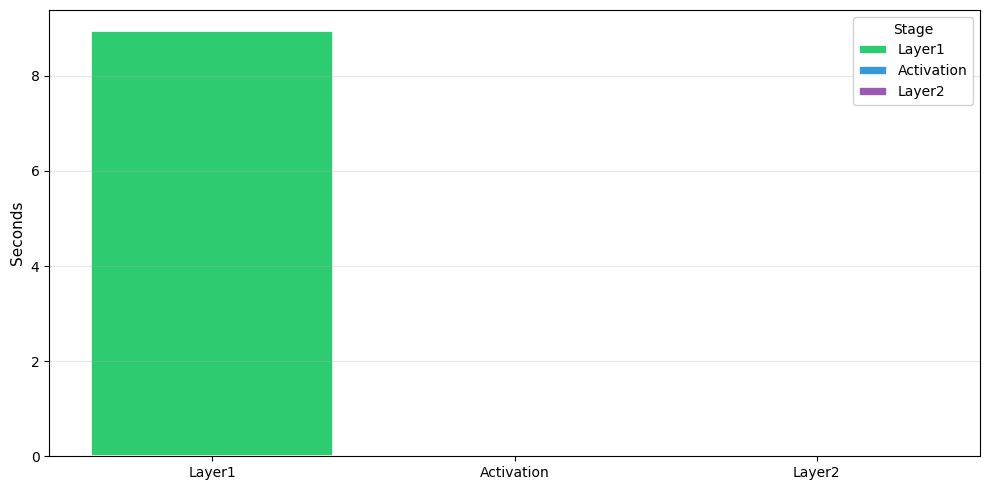

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = ["Layer1", "Activation", "Layer2"]
times = [bench['layer1_time'], bench['activation_time'], bench['layer2_time']]
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax.bar(labels, times, color=colors, edgecolor='white', linewidth=1.2)
ax.set_ylabel('Seconds', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(bars, labels, title='Stage', loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()
